#### Import libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import pickle

#### Dataset Visualization

In [21]:
# Dataset Path
data_path = r"../data/industrial.csv"

# load dataset
df = pd.read_csv(data_path)

# Display the first rows
print(df.head())

              datetime  energy_supplied_kwh  energy_billed_kwh
0  2014-10-11 22:59:47               238.46             235.18
1  2014-10-11 23:59:47               391.64             366.90
2  2014-10-12 00:59:46               518.86             500.06
3  2014-10-12 01:59:45               316.15             302.27
4  2014-10-12 02:59:45               606.16             578.82


In [22]:
# dataset info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99977 entries, 0 to 99976
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             99977 non-null  object 
 1   energy_supplied_kwh  99977 non-null  float64
 2   energy_billed_kwh    99977 non-null  float64
dtypes: float64(2), object(1)
memory usage: 2.3+ MB
None


#### Fixing Missing values

In [23]:
# removing missing values
df = df.dropna()
print("New Shape: ", df.shape)

New Shape:  (99977, 3)


In [24]:
# display features
print(df.columns)

Index(['datetime', 'energy_supplied_kwh', 'energy_billed_kwh'], dtype='object')


In [25]:
# conversion to datetime
df['datetime'] = pd.to_datetime(df['datetime'])

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month

df['loss_kwh'] = df['energy_supplied_kwh'] - df['energy_billed_kwh']
df['loss_ratio'] = df['loss_kwh'] / df['energy_supplied_kwh']
df['rolling_loss_mean'] = df['loss_ratio'].rolling(24).mean()
df['rolling_loss_std'] = df['loss_ratio'].rolling(24).std()

df.head()

,datetime,energy_supplied_kwh,energy_billed_kwh,hour,day,month,loss_kwh,loss_ratio,rolling_loss_mean,rolling_loss_std
0,2014-10-11 22:59:47,238.46,235.18,22,11,10,3.28,0.013755,NaN,NaN
1,2014-10-11 23:59:47,391.64,366.90,23,11,10,24.74,0.063170,NaN,NaN
2,2014-10-12 00:59:46,518.86,500.06,0,12,10,18.80,0.036233,NaN,NaN
3,2014-10-12 01:59:45,316.15,302.27,1,12,10,13.88,0.043903,NaN,NaN
4,2014-10-12 02:59:45,606.16,578.82,2,12,10,27.34,0.045104,NaN,NaN


#### Feature Scaling

In [26]:
# Defining the features

features = df [
    [
        'energy_supplied_kwh',
        'energy_billed_kwh',
        'loss_ratio',
        'hour',
        'day',
        'month',
        'rolling_loss_mean',
        'rolling_loss_std'
    ]
]

scaler = StandardScaler()
X_Scaled = scaler.fit_transform(features)

In [27]:
# Training the model

model = IsolationForest (
    contamination=0.03,
    n_estimators=200,
    random_state=42
)

df['anomaly'] = model.fit_predict(X_Scaled)
df['anomaly_score'] = model.decision_function(X_Scaled)

In [28]:
print(df[['datetime', 'loss_ratio', 'anomaly', 'anomaly_score', 'rolling_loss_mean', 'rolling_loss_std']].head())

             datetime  loss_ratio  anomaly  anomaly_score  rolling_loss_mean  \
0 2014-10-11 22:59:47    0.013755        1       0.077594                NaN   
1 2014-10-11 23:59:47    0.063170        1       0.126782                NaN   
2 2014-10-12 00:59:46    0.036233        1       0.133800                NaN   
3 2014-10-12 01:59:45    0.043903        1       0.117324                NaN   
4 2014-10-12 02:59:45    0.045104        1       0.142121                NaN   

   rolling_loss_std  
0               NaN  
1               NaN  
2               NaN  
3               NaN  
4               NaN  


In [29]:
# Check the number of anomalies
print(df['anomaly'].value_counts())

anomaly
 1    96977
-1     3000
Name: count, dtype: int64


#### Visualize Anomalies

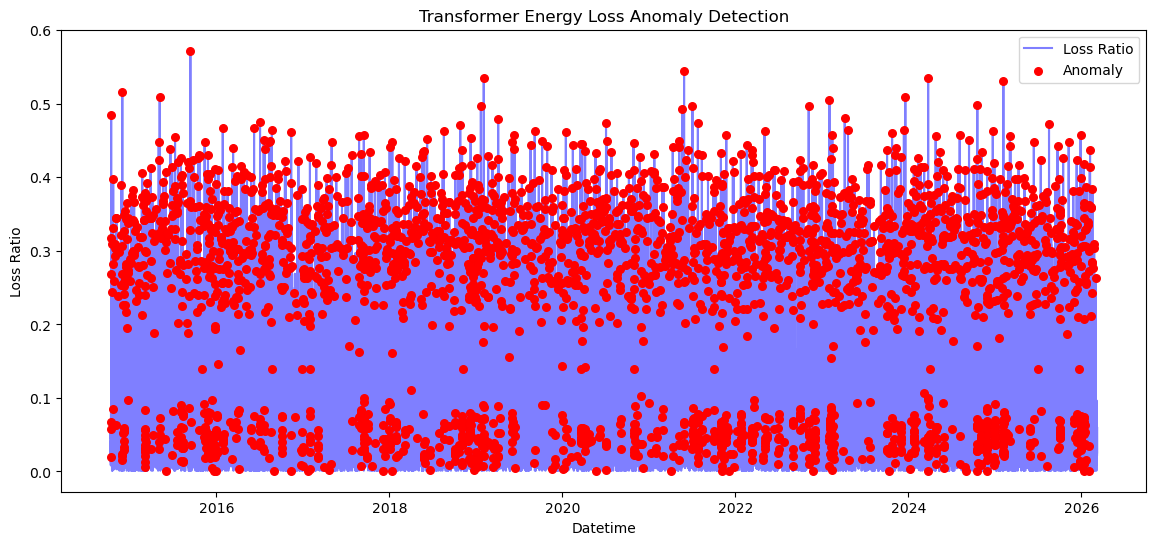

In [30]:
anomalies = df[df['anomaly'] == -1]
plt.figure(figsize=(14,6))

# Normal data
plt.plot (
    df['datetime'],
    df['loss_ratio'],
    label="Loss Ratio",
    color='blue',
    alpha=0.5
)

plt.scatter (
    anomalies['datetime'],
    anomalies['loss_ratio'],
    color='red',
    label='Anomaly',
    s=30,
    zorder=5
)

plt.title("Transformer Energy Loss Anomaly Detection")
plt.xlabel("Datetime")
plt.ylabel("Loss Ratio")

plt.legend()
plt.show()

#### Saving the ML model

In [31]:
import os
os.makedirs('../models', exist_ok=True)

with open('../models/voltguard_industrial_model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'scaler': scaler}, f)

print("Model saved successfully.")

Model saved successfully.


#### Exporting the Anomaly results

In [32]:
os.makedirs('../outputs', exist_ok=True)

anomalies.to_csv('../outputs/industrial_anomalies.csv', index=False)
print("Anomalies exported.")

Anomalies exported.
